#### Ejemplo de aplicación de Gradient Descent Algorithm para encontrar los valores óptimos de un modelo de regresión

Un modelo de regresión lineal tiene la siguiente forma

$$ \hat{y}_i = \beta_0 + \beta_1 x_i + \epsilon_i $$

Para este caso se trabajará con una relación de la forma

$$ y_i = 5 + 3x_i + \epsilon_i  $$

La selección de los valores $\beta_0 = 5$ y $\beta_1 = 3$ es para efectos de la instancia

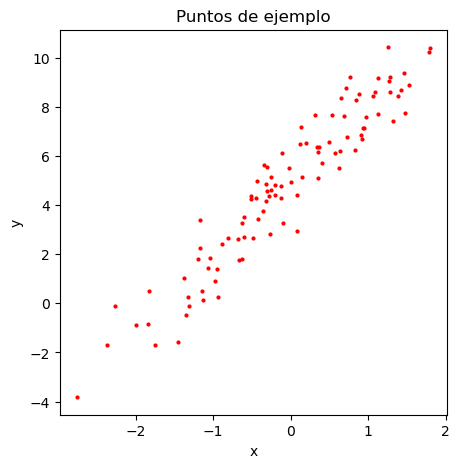

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración del tamaño de la figura
plt.figure(figsize=(5, 5), dpi=100)

# Crear un DataFrame
df = pd.DataFrame({'x': np.random.normal(loc=0, scale=1, size=100)})
df['y'] = 5 + 3 * df['x'] + np.random.normal(loc=0, scale=1, size=100)

# Graficar
plt.scatter(df['x'], df['y'], color='red',s=4)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Puntos de ejemplo')
plt.show()

Un modelo de regresión lineal utiliza el error cuadrático medio como métrica de pérdida para realizar el ajuste de parámetros:

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Se debe tener presente que,

$$ \hat{y}_i = \beta_0 + \beta_1 x_i $$

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1 x_i))^2 $$

Lo que nos deja la siguiente expresión al realizar una sustitución

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2 $$

Aplicando derivada del MSE respecto a $\beta_1$ y $\beta_0$ tenemos lo siguiente,

$$ \frac{\partial MSE}{\partial \beta_1}: \frac{-2}{n}\sum_{i=1}^{n} (y_i x_i - \beta_0 x_i - \beta_1 x_i^2) = D_{\beta_1} $$

$$ \frac{\partial MSE}{\partial \beta_0}: \frac{-2}{n}\sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i) = D_{\beta_0} $$

Con lo anterior podemos escribir nuestra función de actualización,

$$ \beta_{1} = \beta_{1} - \alpha \times D_{\beta_1} $$

$$ \beta_{0} = \beta_0 - \alpha \times D_{\beta_0} $$

En lo anterior $\alpha$ representa la tasa de aprendizaje (learning rate)

In [2]:
# Parámetros para el descenso de gradiente
alpha = 0.01
epocas = 300
n = len(df)

beta_1 = 0
beta_0 = 0
betas_0 = np.zeros(epocas)
betas_1 = np.zeros(epocas)

for i in range(epocas):
    D_b_0 = (-2 / n) * np.sum(df['y'] * df['x'] - beta_0 * df['x'] - beta_1 * df['x']**2)
    D_b_1 = (-2 / n) * np.sum(df['y'] - beta_0 - beta_1 * df['x'])
    beta_1 -= alpha * D_b_0
    beta_0 -= alpha * D_b_1
    betas_1[i] = beta_1
    betas_0[i] = beta_0

print(beta_1)
print(beta_0)

3.017679747759539
4.939107691686517


Podemos visualizar cómo fue el proceso de ajuste de los valores de $\beta_0$ y $\beta_1$ durante la aplicación del algoritmo

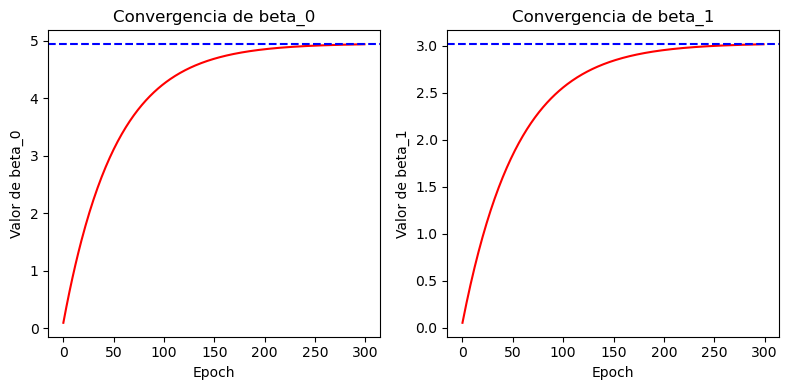

In [3]:
# Crear una figura con dos subgráficos
fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Primer gráfico: Convergencia de beta_0
axs[0].plot(betas_0, color='red')
axs[0].axhline(y=betas_0[-1], linestyle='dashed', color='blue')
axs[0].set_ylabel('Valor de beta_0')
axs[0].set_xlabel('Epoch')
axs[0].set_title('Convergencia de beta_0')

# Segundo gráfico: Convergencia de beta_1
axs[1].plot(betas_1, color='red')
axs[1].axhline(y=betas_1[-1], linestyle='dashed', color='blue')
axs[1].set_ylabel('Valor de beta_1')
axs[1].set_xlabel('Epoch')
axs[1].set_title('Convergencia de beta_1')

# Ajustar el espacio entre los subgráficos
plt.tight_layout()

# Mostrar la figura
plt.show()

In [9]:
# Guardar gráficos de la regresión
import jappy_utils as ju
import imageio.v2 as imageio
import os


ju.setWD('/linear-regression')

gifPath = 'lr-gradiente-anim.gif'
writer = imageio.get_writer(gifPath, mode='I', duration=0.2)
filesImg = []
for i in range(epocas):
    fileImg = f"img-out/lr{i:03d}.png"
    plt.figure(figsize=(5, 5), dpi=100)
    plt.scatter(df['x'], df['y'], color='red', s=4)
    plt.axline((0, betas_0[i]), slope=betas_1[i], color='blue', linewidth=1.5, linestyle='dashed')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Intercepto: {betas_0[i]:.2f} - Pendiente: {betas_1[i]:.2f}')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.savefig(fileImg)
    filesImg.append(fileImg)
    writer.append_data(imageio.imread(fileImg))
    os.remove(fileImg)
    plt.close()

writer.close()

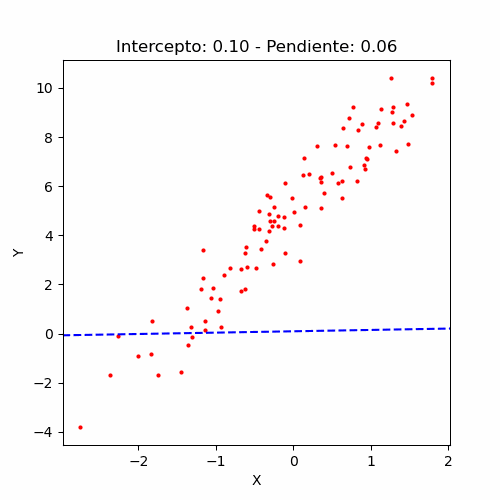

In [10]:
from IPython.display import Image
display(Image(filename=gifPath))